<a href="https://colab.research.google.com/github/tsilva/aiml-notebooks/blob/main/notebooks/wip-gymnasium-temporal-autoencoder.ipynb" target="_parent"><img src="https://colab.research.google.com/assets/colab-badge.svg" alt="Open In Colab"/></a>

# Train Gymnasium with Convolutional Autoencoders with a Bottleneck

## Setup

Install non-optional packages:

In [1]:
!pip install wandb datasets tsilva_notebook_utils==0.0.42

   ━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━ 491.2/491.2 kB 29.7 MB/s eta 0:00:00
   ━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━ 116.3/116.3 kB 10.5 MB/s eta 0:00:00
   ━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━ 183.9/183.9 kB 17.1 MB/s eta 0:00:00
   ━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━ 143.5/143.5 kB 13.8 MB/s eta 0:00:00
   ━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━ 194.8/194.8 kB 16.6 MB/s eta 0:00:00
   ━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━ 1.6/1.6 MB 62.0 MB/s eta 0:00:00
  Attempting uninstall: fsspec
    Found existing installation: fsspec 2025.3.2
    Uninstalling fsspec-2025.3.2:
      Successfully uninstalled fsspec-2025.3.2
ERROR: pip's dependency resolver does not currently take into account all the packages that are installed. This behaviour is the source of the following dependency conflicts.
torch 2.6.0+cu124 requires nvidia-cublas-cu12==12.4.5.8; platform_system == "Linux" and platform_machine == "x86_64", but you have nvidia-cublas-cu12 12.5.3.2 which is incompatible.


🔑 Loading API keys and authentication tokens from Colab secrets:

In [2]:
from tsilva_notebook_utils.colab import load_secrets_into_env

load_secrets_into_env([
    'WANDB_API_KEY',
    'NOTIFICATION_URL',
    'NOTIFICATION_AUTH_TOKEN'
])

['150cf7fd55e30189bacd411eb8c80e7fd065872a',
 'https://pleasing-foal-yearly.ngrok-free.app',
 '57c56029-095d-45af-85a1-a2d77d6ef3eb']

Define configuration:

In [3]:
import os
from tsilva_notebook_utils.colab import notebook_id_from_title

def setup_config():
    # @markdown ### 🏋️ Notebook Settings

    # @markdown Random seed used for reproducibility across runs
    seed = 42  # @param {type: "integer"}

    # @markdown ### 🗂️ Dataset Settings

    # @markdown Dataset ID to load gameplay recordings from
    dataset_id = "tsilva/GymnasiumRecording__Tetris_GameBoy"  # @param {type: "string"}

    # @markdown Number of consecutive frames to stack as input
    frame_stack_size = 1  # @param {type: "number"}

    # @markdown Number of frames to skip between inputs
    frame_skip = 4  # @param {type: "number"}

    # @markdown Scale factor for input image resizing (e.g., 0.5 = half size)
    image_scale = 0.5  # @param {type: "number"}

    # @markdown Image mode used: grayscale, color, or black-and-white
    image_mode = "grayscale"  # @param ["color", "grayscale", "black_and_white"]

    # @markdown Number of colors to use when quantizing the image (used in black-and-white mode)
    image_quantize_colors = 2  # @param {type: "number"}

    # @markdown Crop paddings (left, top, right, bottom) applied to input image
    image_crop_paddings = "0,64,0,16"  # @param {type: "string"}

    # @markdown Amount of random noise added to inputs during training
    image_noise_factor = 0  # @param {type: "number"}

    # @markdown ### 🧠 Model Settings

    # @markdown Dimensionality of the learned latent space
    latent_dim = 16  # @param {type: "number"}

    # @markdown Amount of noise to add to the latent representation (regularization)
    latent_noise_factor = 0.0  # @param {type: "number"}

    # @markdown Small constant added to latent computations for numerical stability
    latent_sparsity_epsilon = 1e-3  # @param {type: "number"}

    # @markdown ### ✅ Validation Settings

    # @markdown Number of epochs between each validation run
    validation_epochs = 10  # @param {type: "number"}

    # @markdown ### 🏋️ Training Settings

    # @markdown Total number of training epochs
    n_epochs = 1000  # @param {type: "integer"}

    # @markdown Number of samples per training batch
    batch_size = 128  # @param {type: "integer"}

    # @markdown Maximum gradient norm for clipping (0 = no clipping)
    max_grad_norm = 0  # @param {type: "number"}

    # @markdown L2 weight decay added to the optimizer (0 = none)
    weight_decay = 0  # @param {type: "number"}

    # @markdown Proportion of total steps used for learning rate warmup
    warmup_ratio = 0  # @param {type: "number"}

    # @markdown Loss function to use (e.g., 'mse', 'mae')
    loss_function = "mse"  # @param ["mse", "mae"]

    # @markdown Weight for the sparsity loss component (helps compress representations)
    latent_sparsity_loss_alpha = 0.1  # @param {type: "number"}

    # @markdown Learning rate used by the optimizer
    learning_rate = 0.001  # @param {type: "number"}

    # Set notebook ID in the environment (not returned)
    os.environ["NOTEBOOK_ID"] = notebook_id_from_title()

    return dict(
        # Notebook
        seed=seed,
        validation_epochs=validation_epochs,

        # Dataset
        dataset_id=dataset_id,
        frame_skip=frame_skip,
        frame_stack_size=frame_stack_size,
        image_scale=image_scale,
        image_mode=image_mode,
        image_quantize_colors=image_quantize_colors,
        image_crop_paddings=image_crop_paddings,
        image_noise_factor=image_noise_factor,

        # Model
        latent_dim=latent_dim,
        latent_noise_factor=latent_noise_factor,
        latent_sparsity_epsilon=latent_sparsity_epsilon,

        # Training
        n_epochs=n_epochs,
        batch_size=batch_size,
        max_grad_norm=max_grad_norm,
        weight_decay=weight_decay,
        warmup_ratio=warmup_ratio,
        loss_function=loss_function,
        learning_rate=learning_rate,
        latent_sparsity_loss_alpha=latent_sparsity_loss_alpha
    )

CONFIG = setup_config()

Enable cudnn benchmarking to select optimal cuda kernels:

In [4]:
#import torch
#torch.backends.cudnn.benchmark = True

Login to wandb:

In [5]:
from wandb import login
login()

wandb: Using wandb-core as the SDK backend.  Please refer to https://wandb.me/wandb-core for more information.
wandb: Currently logged in as: tsilva to https://api.wandb.ai. Use `wandb login --relogin` to force relogin


True

Load dataset:

In [6]:
from datasets import load_dataset
dataset = load_dataset(CONFIG["dataset_id"], split="train")
dataset

README.md:   0%|          | 0.00/386 [00:00<?, ?B/s]

train-00000-of-00001.parquet:   0%|          | 0.00/15.2M [00:00<?, ?B/s]

Generating train split:   0%|          | 0/36054 [00:00<?, ? examples/s]

Dataset({
    features: ['episode_id', 'image', 'step', 'action'],
    num_rows: 36054
})

Deduplicate dataset:

In [7]:
from tsilva_notebook_utils.huggingface import dedupe_dataset
deduped_dataset = dedupe_dataset(dataset, "image")
deduped_dataset

Filter:   0%|          | 0/36054 [00:00<?, ? examples/s]

Dataset({
    features: ['episode_id', 'image', 'step', 'action'],
    num_rows: 5012
})

Show sample dataset image:

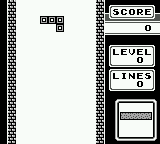

In [8]:
sample_image = dataset[0]["image"]
sample_image

Process image:

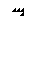

In [9]:
from tsilva_notebook_utils.huggingface import process_images
from torchvision.transforms.functional import to_pil_image

PROCESS_IMAGE_CONFIG = {
    "mode" : CONFIG["image_mode"],
    "quantize_colors" : CONFIG["image_quantize_colors"],
    "scale" : CONFIG["image_scale"],
    "crop_paddings" : [int(x) for x in CONFIG["image_crop_paddings"].split(",")],
    "noise_factor" : CONFIG["image_noise_factor"]
}
processed_image_t = process_images([sample_image], **PROCESS_IMAGE_CONFIG)[0]
processed_image = to_pil_image(processed_image_t)
processed_image

Retrieve image dimensions:

In [10]:
image_channels, image_height, image_width = processed_image_t.shape
image_channels, image_height, image_width

(1, 72, 40)

Add processed images to dataset:

In [11]:
def _map_process_images(batch):
    inputs = targets = process_images(batch["image"], **PROCESS_IMAGE_CONFIG)
    return dict(
        input=inputs,
        target=targets
    )
processed_dataset = deduped_dataset.map(
    _map_process_images,
    batched=True,
    batch_size=64
)

Map:   0%|          | 0/5012 [00:00<?, ? examples/s]

Create train and validation datasets (validation dataset only has every Nth frame, train dataset has all frames except those):

In [12]:
import torch
from torch.utils.data import DataLoader

frame_skip = CONFIG['frame_skip']
test_dataset = processed_dataset.remove_columns(['episode_id', 'image', 'step', 'action'])
test_dataset = test_dataset.with_format("torch")
mask = torch.arange(len(test_dataset)) % frame_skip == 0
train_dataset = test_dataset.select(torch.nonzero(~mask).squeeze()).with_format("torch")
validation_dataset = test_dataset.select(torch.nonzero(mask).squeeze()).with_format("torch")
train_dataset, validation_dataset

(Dataset({
     features: ['input', 'target'],
     num_rows: 3759
 }),
 Dataset({
     features: ['input', 'target'],
     num_rows: 1253
 }))

Create dataset loaders:

In [13]:
import multiprocessing

train_loader = DataLoader(
    train_dataset,
    batch_size=CONFIG["batch_size"],
    shuffle=True,
    pin_memory=True,
    num_workers=multiprocessing.cpu_count(),
    prefetch_factor=4
)

validation_loader = DataLoader(
    validation_dataset,
    batch_size=CONFIG["batch_size"],
    pin_memory=True,
    shuffle=False,
    num_workers=multiprocessing.cpu_count(),
    prefetch_factor=4
)

test_loader = DataLoader(
    test_dataset,
    batch_size=CONFIG["batch_size"],
    pin_memory=True,
    shuffle=False,
    num_workers=multiprocessing.cpu_count()
)

Render validation loader to make sure to make sure everything is ok:

In [14]:
from tsilva_notebook_utils.video import render_loader_video
render_loader_video(validation_loader, scale=2)

Rendering frames: 100%|██████████| 10/10 [00:01<00:00,  7.81it/s]


Create the model:

In [15]:
import torch
import torch.nn as nn
import torch.optim as optim
from torch.utils.data import DataLoader
from torchvision import transforms
from datasets import load_dataset
from tsilva_notebook_utils.torch import get_current_device

class ConvAutoencoder(nn.Module):
    def __init__(self, input_channels, output_channels, input_height, input_width, latent_dim=None, use_bottleneck=True):
        super(ConvAutoencoder, self).__init__()

        self.latent_noise_factor = CONFIG['latent_noise_factor']

        if latent_dim is None: latent_dim = CONFIG['latent_dim']
        self.use_bottleneck = use_bottleneck

        # --- Encoder ---
        self.encoder_conv = nn.Sequential(
            nn.Conv2d(input_channels, 32, 3, padding=1),
            nn.ReLU(),
            nn.MaxPool2d(2, 2),

            nn.Conv2d(32, 64, 3, padding=1),
            nn.ReLU(),
            nn.MaxPool2d(2, 2),

            nn.Conv2d(64, 128, 3, padding=1),
            nn.ReLU(),
            nn.MaxPool2d(2, 2)
        )

        # Dummy forward pass to compute shape
        with torch.no_grad():
            dummy_input = torch.zeros(1, input_channels, input_height, input_width)
            dummy_output = self.encoder_conv(dummy_input)
            self._flattened_size = dummy_output.numel()
            self._conv_output_shape = dummy_output.shape[1:]

        if self.use_bottleneck:
            self.fc_enc = nn.Linear(self._flattened_size, latent_dim)
            self.fc_dec = nn.Linear(latent_dim, self._flattened_size)

        # --- Decoder ---
        self.decoder_conv = nn.Sequential(
            nn.ConvTranspose2d(128, 64, 2, stride=2),
            nn.ReLU(),

            nn.ConvTranspose2d(64, 32, 2, stride=2),
            nn.ReLU(),

            nn.ConvTranspose2d(32, output_channels, 2, stride=2),
            nn.Sigmoid()
        )

    def encode(self, x):
        x = self.encoder_conv(x)
        if self.use_bottleneck:
            x = x.view(x.size(0), -1)
            x = self.fc_enc(x)
        return x

    def decode(self, z):
        if self.use_bottleneck:
            z = self.fc_dec(z)
            z = z.view(z.size(0), *self._conv_output_shape)
        else:
            z = z  # z already in conv shape
        z = self.decoder_conv(z)
        return z

    def forward(self, x):
        z = self.encode(x)

        # Add noise to latent space
        if self.training and self.latent_noise_factor > 0: # TODO: move to init
            noise = torch.randn_like(z) * self.latent_noise_factor
            z_noisy = z + noise
        else:
            z_noisy = z

        out = self.decode(z_noisy)
        return out, z

frame_stack_size = CONFIG['frame_stack_size']
latent_dim = CONFIG['latent_dim']
use_bottleneck = latent_dim > 0
input_channels = frame_stack_size * image_channels
output_channels = image_channels
device = get_current_device()
model = ConvAutoencoder(input_channels, output_channels, image_height, image_width, use_bottleneck=use_bottleneck).to(device)
model

ConvAutoencoder(
  (encoder_conv): Sequential(
    (0): Conv2d(1, 32, kernel_size=(3, 3), stride=(1, 1), padding=(1, 1))
    (1): ReLU()
    (2): MaxPool2d(kernel_size=2, stride=2, padding=0, dilation=1, ceil_mode=False)
    (3): Conv2d(32, 64, kernel_size=(3, 3), stride=(1, 1), padding=(1, 1))
    (4): ReLU()
    (5): MaxPool2d(kernel_size=2, stride=2, padding=0, dilation=1, ceil_mode=False)
    (6): Conv2d(64, 128, kernel_size=(3, 3), stride=(1, 1), padding=(1, 1))
    (7): ReLU()
    (8): MaxPool2d(kernel_size=2, stride=2, padding=0, dilation=1, ceil_mode=False)
  )
  (fc_enc): Linear(in_features=5760, out_features=512, bias=True)
  (fc_dec): Linear(in_features=512, out_features=5760, bias=True)
  (decoder_conv): Sequential(
    (0): ConvTranspose2d(128, 64, kernel_size=(2, 2), stride=(2, 2))
    (1): ReLU()
    (2): ConvTranspose2d(64, 32, kernel_size=(2, 2), stride=(2, 2))
    (3): ReLU()
    (4): ConvTranspose2d(32, 1, kernel_size=(2, 2), stride=(2, 2))
    (5): Sigmoid()
  )
)

In [16]:
model = torch.compile(model)
model

OptimizedModule(
  (_orig_mod): ConvAutoencoder(
    (encoder_conv): Sequential(
      (0): Conv2d(1, 32, kernel_size=(3, 3), stride=(1, 1), padding=(1, 1))
      (1): ReLU()
      (2): MaxPool2d(kernel_size=2, stride=2, padding=0, dilation=1, ceil_mode=False)
      (3): Conv2d(32, 64, kernel_size=(3, 3), stride=(1, 1), padding=(1, 1))
      (4): ReLU()
      (5): MaxPool2d(kernel_size=2, stride=2, padding=0, dilation=1, ceil_mode=False)
      (6): Conv2d(64, 128, kernel_size=(3, 3), stride=(1, 1), padding=(1, 1))
      (7): ReLU()
      (8): MaxPool2d(kernel_size=2, stride=2, padding=0, dilation=1, ceil_mode=False)
    )
    (fc_enc): Linear(in_features=5760, out_features=512, bias=True)
    (fc_dec): Linear(in_features=512, out_features=5760, bias=True)
    (decoder_conv): Sequential(
      (0): ConvTranspose2d(128, 64, kernel_size=(2, 2), stride=(2, 2))
      (1): ReLU()
      (2): ConvTranspose2d(64, 32, kernel_size=(2, 2), stride=(2, 2))
      (3): ReLU()
      (4): ConvTranspose2

Test a forward pass through the model to make sure shapes are accurate:

In [17]:
def plot_loader_embeddings(loader):
    from tsilva_notebook_utils.plots import plot_embeddings_with_inputs

    z_list = []
    x_images = []
    for batch in validation_loader:
        x = batch["input"].to(device)
        with torch.no_grad(): y_pred, z = model(x)
        z_list.append(z.detach().cpu())
        x_images.extend([to_pil_image(_x) for _x in x.detach().cpu().unbind(0)])

    z_all = torch.cat(z_list, dim=0)
    z_latent_np = z_all.numpy()
    plot_embeddings_with_inputs(z_latent_np, x_images)

plot_loader_embeddings(test_loader)

/usr/local/lib/python3.11/dist-packages/torch/_inductor/compile_fx.py:194: UserWarning: TensorFloat32 tensor cores for float32 matrix multiplication available but not enabled. Consider setting `torch.set_float32_matmul_precision('high')` for better performance.
  warnings.warn(
W0424 11:53:10.282000 1341 torch/_inductor/utils.py:1137] [0/0] Not enough SMs to use max_autotune_gemm mode


In [18]:
from tsilva_notebook_utils.video import render_video_from_frames

def decode_zs(zs):
    zs = zs.to(device)
    with torch.no_grad(): logits = model.decode(zs)
    return logits

zs = []
latent_dim = CONFIG['latent_dim']
for i in range(latent_dim):
    z = torch.zeros(latent_dim, device=device)
    z[i] = 1.0
    zs.append(z)
zs = torch.stack(zs)

frames_t = decode_zs(zs)
render_video_from_frames(frames_t, fps=10, scale=2)

Saving frames: 100%|██████████| 512/512 [00:00<00:00, 3495.53it/s]


In [ ]:
from tsilva_notebook_utils.video import render_autoencoder_video
render_autoencoder_video(validation_loader, scale=2)

Create model, loss function and optimizer:

In [23]:
if CONFIG['loss_function'] == 'mse':
    loss_fn = nn.MSELoss()
elif CONFIG['loss_function'] == 'ssim':
    from pytorch_msssim import MS_SSIM
    ms_ssim = MS_SSIM(data_range=1.0, size_average=True, channel=image_channels)
    loss_fn = lambda pred, target: 1 - ms_ssim(pred, target)

optimizer = optim.AdamW(model.parameters(), lr=CONFIG["learning_rate"], weight_decay=CONFIG["weight_decay"], fused=True)

Run training:

In [ ]:
import os
import torch
import random
from torch import autocast
from torch.nn.utils import clip_grad_norm_
from torch.optim.lr_scheduler import LambdaLR
from torch.amp import GradScaler
from tqdm import tqdm
import wandb

from tsilva_notebook_utils.torch import get_device_from_model, calc_model_grad_norms, get_conv_filter_images

def train(
    model,
    loss_fn,
    optimizer,
    train_loader,
    n_epochs=None,
    eval_fn=None,
    learning_rate=None,
    max_grad_norm=None,
    warmup_ratio=None,
    validation_loader=None
):
    NOTEBOOK_ID = os.getenv("NOTEBOOK_ID")
    assert NOTEBOOK_ID, "NOTEBOOK_ID environment variable is not set"

    with wandb.init(project=NOTEBOOK_ID, config=CONFIG) as run:
        # Pull hyperparameters from CONFIG or arguments
        config = run.config
        n_epochs = n_epochs or config.get('n_epochs', 10)
        learning_rate = learning_rate or config.get('learning_rate', 1e-3)
        max_grad_norm = max_grad_norm or config.get('max_grad_norm', 1.0)
        warmup_ratio = warmup_ratio or config.get('warmup_ratio', 0.1)

        device = get_device_from_model(model)
        scaler = GradScaler(enabled=(device.type == "cuda"))
        wandb.watch(model, log="all")

        total_steps = n_epochs * len(train_loader)
        warmup_steps = int(warmup_ratio * total_steps)

        scheduler = LambdaLR(optimizer, lr_lambda=lambda step: step / max(1, warmup_steps) if step < warmup_steps else 1.0)

        global_step = 0

        for epoch in tqdm(range(n_epochs), desc="Training"):
            model.train()
            epoch_losses, reconstruction_losses, sparsity_losses = [], [], []

            epoch_xs = []
            epoch_zs = []
            epoch_logits = []
            for batch in train_loader:
                x = batch["input"].to(device)
                y = batch["target"].to(device)

                optimizer.zero_grad()
                global_step += 1

                with autocast(device_type=device.type, enabled=(device.type == "cuda")):
                    logits, z = model(x)
                    epoch_xs.append(x.detach().cpu())
                    epoch_zs.append(z.detach().cpu())
                    epoch_logits.append(logits.detach().cpu())

                    recon_loss = loss_fn(logits, y)
                    latent_alpha = config.get('latent_sparsity_loss_alpha', 0.0)
                    sparsity_loss = latent_alpha * torch.mean(torch.abs(z)) if latent_alpha > 0 else 0.0
                    loss = recon_loss + sparsity_loss

                scaler.scale(loss).backward()

                if max_grad_norm:
                    scaler.unscale_(optimizer)
                    clip_grad_norm_(model.parameters(), max_grad_norm)

                scaler.step(optimizer)
                scaler.update()
                scheduler.step()

                # Track losses
                epoch_losses.append(loss.item())
                reconstruction_losses.append(recon_loss.item())
                if latent_alpha > 0:
                    sparsity_losses.append(sparsity_loss.item())

            # Validation phase
            val_loss = None
            if validation_loader and epoch % config.get('validation_epochs', 1) == 0:
                model.eval()
                val_losses = [
                    loss_fn(model(batch["input"].to(device))[0], batch["target"].to(device)).item()
                    for batch in validation_loader
                ]
                val_loss = sum(val_losses) / len(val_losses)

            epoch_xs = torch.cat(epoch_xs, dim=0)
            epoch_logits = torch.cat(epoch_logits, dim=0)
            epoch_zs = torch.cat(epoch_zs, dim=0)

            # Collect latent stats
            epsilon = config.get("latent_sparsity_epsilon", 1e-3)
            activation_rate = (epoch_zs.abs() > epsilon).float().mean(dim=0)

            # Logging to wandb
            wandb_stats = {
                "meta/epoch": epoch + 1,
                "meta/step": global_step,
                "meta/learning_rate": scheduler.get_last_lr()[0],
                "train/loss": sum(epoch_losses) / len(epoch_losses),
                "train/reconstruction_loss": sum(reconstruction_losses) / len(reconstruction_losses),
                "latent_z/sparsity": (epoch_zs.abs() < epsilon).float().mean().item(),
                "latent_z/active_ratio": activation_rate.mean().item(),
                "latent_z/min": epoch_zs.min().item(),
                "latent_z/max": epoch_zs.max().item(),
                "latent_z/mean": epoch_zs.mean().item(),
                "latent_z/std": epoch_zs.std().item(),
                "latent_z/l2_norm": epoch_zs.norm(p=2).item(),
                "latent_z/l1_norm": epoch_zs.norm(p=1).item(),
                "latent_z/hist": wandb.Histogram(epoch_zs.numpy()),
                "latent_z/activation_per_dim": wandb.Histogram(activation_rate.cpu().numpy())
            }
            if sparsity_losses:
                wandb_stats["train/sparsity_loss"] = sum(sparsity_losses) / len(sparsity_losses)

            # Optional latent visualizations
            results = plot_tensor_batch_stats_as_heatmaps(epoch_zs, title_prefix="Latent Analysis", stats=["mean", "std", "var"])
            for key, image in results.items():
                wandb_stats[f"latent_z/{key}_heatmap"] = wandb.Image(image)

            # Sample one reconstruction pair per step
            sample_idx = random.randrange(len(epoch_xs))
            sample_x = epoch_xs[sample_idx]
            sample_logits = epoch_logits[sample_idx]
            concat_img = torch.cat([sample_x.cpu(), sample_logits.cpu()], dim=2)
            wandb_stats["reconstruction/pair"] = wandb.Image(
                to_pil_image(concat_img),
                caption="x|y_pred"
            )

            filter_images = get_conv_filter_images(model)
            for key, image in filter_images.items():
                wandb_stats[f"filters/{key}"] = wandb.Image(image)

            # Add eval metrics if provided
            if eval_fn:
                eval_results = eval_fn()
                wandb_stats.update({
                    "val/loss": eval_results.get("loss"),
                    "val/accuracy": eval_results.get("accuracy")
                })

            wandb.log(wandb_stats, step=global_step)

        return run

train(model, loss_fn, optimizer, train_loader)

Training:  19%|█▉        | 190/1000 [13:00<1:00:23,  4.47s/it]

Plot the test dataset embedding post training:

In [ ]:
plot_loader_embeddings(test_loader)

Render video of autoencoder predictions:

In [ ]:
render_autoencoder_video(model, validation_loader, fps=10, scale=2)

In [ ]:
from tsilva_notebook_utils.torch import get_device_from_model
from tsilva_notebook_utils.video import render_video_from_frames

def encode_loader(loader):
    zs = []
    for batch in test_loader:
      x_batch = batch["input"].to(device)
      with torch.no_grad(): z = model.encode(x_batch)
      zs.append(z.detach().cpu())
    zs = torch.cat(zs)
    return zs

zs = encode_loader(test_loader)
mean = zs.mean(dim=0)
cov = torch.cov(zs.T)
mvn = torch.distributions.MultivariateNormal(mean, covariance_matrix=cov)
zs = mvn.sample((1000,))
logits = decode_zs(zs)
frames_t = logits.unbind(0)
render_video_from_frames(frames_t)

⏰ Setting up auto-notification and resource management:

In [ ]:
from tsilva_notebook_utils.colab import notify_and_disconnect_after_timeout
notify_and_disconnect_after_timeout()